In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1: Data Preprocessing and Merging

In [2]:
# loading datasets
customers = pd.read_csv('../dataset/olist_customers_dataset.csv')
orders = pd.read_csv('../dataset/olist_orders_dataset.csv')
items = pd.read_csv('../dataset/olist_order_items_dataset.csv')

# merging data
df = pd.merge(orders, customers, on='customer_id', how='left')
df = pd.merge(df, items, on='order_id', how='left')

final_df = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'price', 'order_status']].copy()
final_df['order_purchase_timestamp'] = pd.to_datetime(final_df['order_purchase_timestamp'])

final_df.head()




,customer_unique_id,order_id,order_purchase_timestamp,price,order_status
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,delivered
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,delivered
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,delivered
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,delivered
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,delivered


In [3]:
final_df.shape

(113425, 5)

In [4]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_unique_id        113425 non-null  str           
 1   order_id                  113425 non-null  str           
 2   order_purchase_timestamp  113425 non-null  datetime64[us]
 3   price                     112650 non-null  float64       
 4   order_status              113425 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 12.3 MB


In [5]:
# dropping missing price rows :
final_df = final_df.dropna(subset=['price'])

In [6]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 112650 entries, 0 to 113424
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_unique_id        112650 non-null  str           
 1   order_id                  112650 non-null  str           
 2   order_purchase_timestamp  112650 non-null  datetime64[us]
 3   price                     112650 non-null  float64       
 4   order_status              112650 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 13.0 MB


In [7]:
# price analysis :
price_analysis = final_df['price'].describe()
price_analysis

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [8]:
all_statuses = final_df['order_status'].value_counts()
all_statuses

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [9]:
# filtering for delivered orders :
final_df = final_df[final_df['order_status']=="delivered"].copy()

final_df['order_status'].value_counts()

order_status
delivered    110197
Name: count, dtype: int64

## Phase 2: RFM Calculation
### RFM Analysis:

In [10]:
# Snapshot date :
snapshot_date = final_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# RFM aggregation
rfm = final_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                              # Frequency
    'price': 'sum'                                                       # Monetary
})

# Rename colums
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
0000f46a3911fa3c0805444483337064,537,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
0004aac84e0df4da2b147fca70cf8255,288,1,180.00


### RFM Scoring:

In [11]:
# R_score: Less recency higher score :
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# F_score: Higher frequency higher score :
# Note: Frequency values repeating so, using rank method :
rfm['F_score'] = rfm['Frequency'].rank(method='first')
rfm['F_score'] = pd.qcut(rfm['F_score'], 5, labels=[1, 2, 3, 4, 5])

# M_score: Higher monetary higher score :
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Final RFM Score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

## Phase 3: Customer Segmentation

In [12]:
# Segment mapping dictionary
segs = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose Them',
    r'3[1-2]': 'About To Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# Generating segment by combining R and F :
rfm['Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segs, regex=True)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414,Promising
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411,Promising
0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112,Hibernating
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211,Hibernating
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215,Hibernating


In [13]:
rfm['Segment'].value_counts()

Segment
Loyal Customers        15005
Potential Loyalists    14993
Hibernating            14986
At Risk                14936
Champions               7535
About To Sleep          7373
Can't Loose Them        7294
Promising               3759
Need Attention          3757
New Customers           3720
Name: count, dtype: int64

In [14]:
import plotly.express as px

# Segment counts dataFrame :
df_counts = rfm['Segment'].value_counts().reset_index()
df_counts.columns = ['Segment', 'Count']

# Treemap Plot
fig = px.treemap(df_counts, path=['Segment'], values='Count', 
                 title='Customer Segmentation Overview',
                 color='Count', color_continuous_scale='RdBu')
fig.write_image("outputs/customer_segmentation.png")
fig.show()

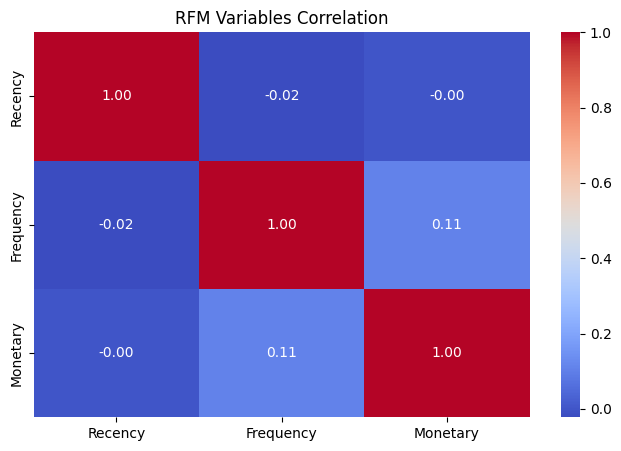

In [15]:
# correlation plot :
plt.figure(figsize=(8, 5))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('RFM Variables Correlation')
plt.savefig('outputs/correlation.png')
plt.show()

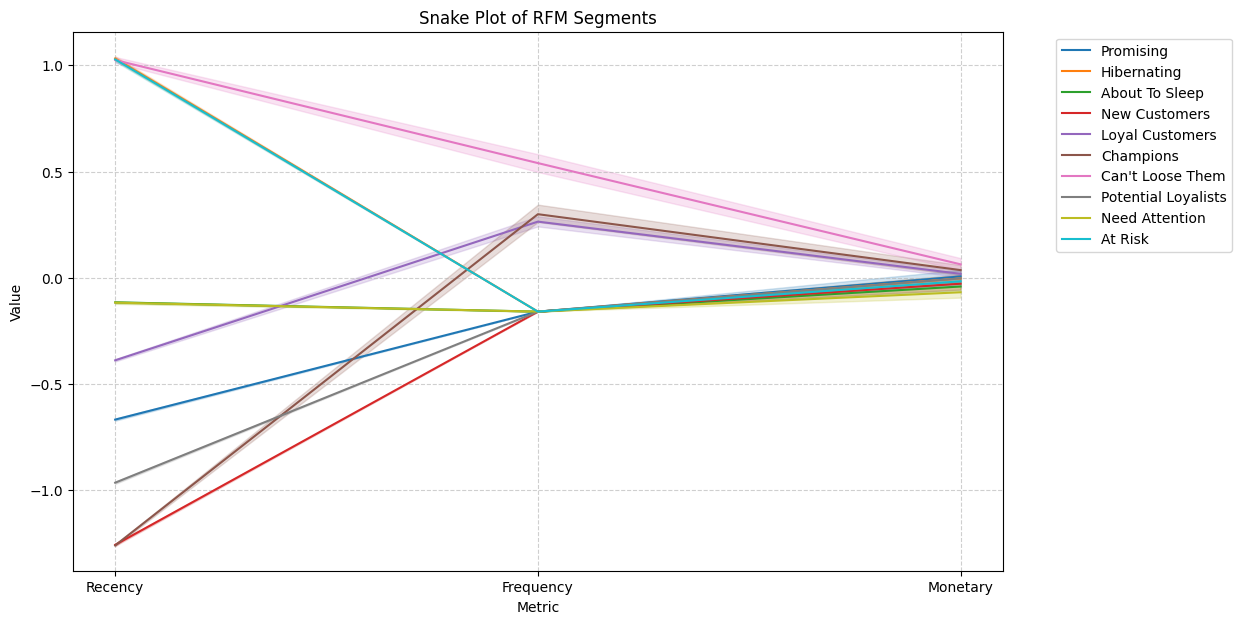

In [16]:
# snake plot :
from sklearn.preprocessing import StandardScaler

# Step 1: Normalizing Data :
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# new dataFrame :
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Segment'] = rfm['Segment']

# Step 2: Melting Data :
rfm_melted = pd.melt(rfm_scaled_df.reset_index(), 
                     id_vars=['customer_unique_id', 'Segment'], 
                     value_vars=['Recency', 'Frequency', 'Monetary'], 
                     var_name='Metric', 
                     value_name='Value')

# Step 3: Snake Plot :
plt.figure(figsize=(12, 7))
plt.title('Snake Plot of RFM Segments')
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='Segment', palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('outputs/snake_plot.png')
plt.show()

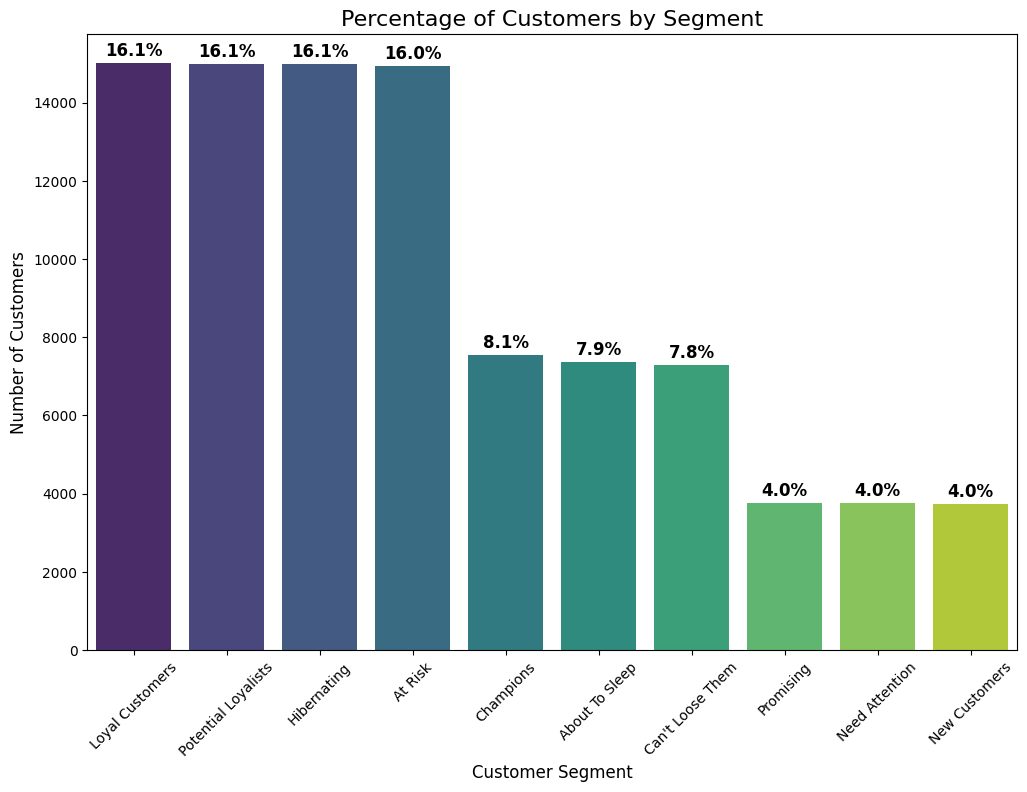

In [17]:
# finding segment counts and percentages :
segment_counts = rfm['Segment'].value_counts()
segment_percentage = (rfm['Segment'].value_counts(normalize=True) * 100).round(1)

# Plotting :
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=segment_counts.index, 
    y=segment_counts.values, 
    hue=segment_counts.index, 
    palette='viridis', 
    legend=False
)

for i, p in enumerate(ax.patches):
    percentage = segment_percentage.iloc[i]
    ax.annotate(f'{percentage}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Percentage of Customers by Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('outputs/bar_chat.png')
plt.show()

In [18]:
# for streamlit : 
rfm.to_csv('rfm_data.csv', index=True)